<a href="https://colab.research.google.com/github/mengchi0202/Data-Science/blob/main/%E3%80%8CData_Science%E3%80%8D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment Setup

In [ ]:
# 處理 gurobipy 授權
!pip install gurobipy==10.0.1
import gurobipy as gp
from gurobipy import GRB

# WLS credentials
wls_access_id = '0943b55a-884b-4b34-96fd-937a0a8b85d0'
wls_secret_key = '43bdb752-e997-45dc-b6d8-839a2127f289'
license_id = 2676229

# 建立 Gurobi WLS 環境
env = gp.Env(empty=True)
env.setParam("WLSACCESSID", wls_access_id)
env.setParam("WLSSECRET", wls_secret_key)
env.setParam("LICENSEID", license_id)
env.start()

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2676229
Academic license 2676229 - for non-commercial use only - registered to 11___@nccu.edu.tw


<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=2676229>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder
from gurobipy import Model
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt

# Attempt to mount Google Drive
try:
    drive.mount('/content/drive')
except Exception as e:
    print(f"An error occurred during Drive mount: {e}")
    print("Please try running the cell again. If the issue persists, consider restarting the Colab runtime.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Pre-processing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = "/content/drive/My Drive/stores_sales_forecasting.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')

import os

file_path = "/content/drive/My Drive/stores_sales_forecasting.csv"

if os.path.exists(file_path):
    print("檔案存在")
else:
    print("找不到檔案")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
檔案存在


In [ ]:
df = pd.read_csv("/content/drive/My Drive/stores_sales_forecasting.csv", encoding='ISO-8859-1')

In [ ]:
# Row ID: Unique identifier for each entry.
# Order ID: Unique order identifier.
# Order Date: Date when the order was placed.
# Ship Date: Date when the order was shipped.
# Ship Mode: Shipping method used.
# Customer ID: Unique identifier for each customer.
# Customer Name: Name of the customer.
# Segment: Market segment (e.g., Consumer, Corporate).
# Country: Country where the order was placed.
# City: City where the order was placed.
# State: State where the order was placed.
# Postal Code: Postal code of the customer.
# Region: Geographic region.
# Product ID: Unique identifier for the product.
# Category: Category of the product (e.g., Furniture, Office Supplies).
# Sub-Category: Sub-category of the product.
# Product Name: Name of the product.
# Sales: Total sales amount.
# Quantity: Quantity of items purchased.
# Discount: Discount applied.
# Profit: Profit generated from the sale.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [ ]:
df = df.drop(columns=['Row ID'])
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [ ]:
# check whether there are any duplicate rows in the dataset
duplicate_rows = df[df.duplicated()]
duplicate_rows.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
720,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


In [ ]:
# remove duplicate rows
df = df.drop_duplicates()
duplicate_rows = df[df.duplicated()]
duplicate_rows.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


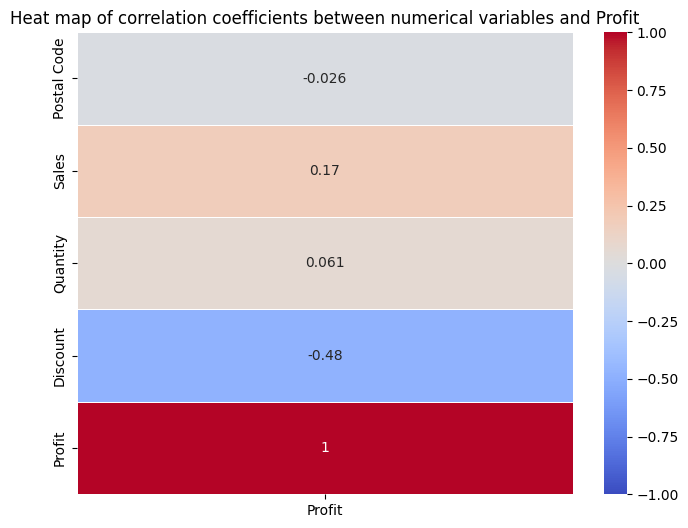

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])# 選出數值型變數
corr_matrix = numeric_df.corr()# 計算相關係數矩陣

# 畫相關係數熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix[['Profit']], annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heat map of correlation coefficients between numerical variables and Profit')
plt.show()

In [ ]:
# 主要使用 Profit, Discount, Sub-Category
df_model = df[['Profit', 'Discount', 'Sub-Category']].copy()

# 處理類別變數 categorical variables 'Sub-Category'
encoder = OneHotEncoder(sparse_output=False, drop='first')
subcat_encoded = encoder.fit_transform(df_model[['Sub-Category']])
subcat_cols = encoder.get_feature_names_out(['Sub-Category'])

# 加入 dummy features
df_subcat = pd.DataFrame(subcat_encoded, columns=subcat_cols, index=df_model.index)
df_model = df_model.drop(columns='Sub-Category')
df_model = pd.concat([df_model, df_subcat], axis=1)


# Part I. Unconstraint Spline Regression with 5-Fold CV

In [ ]:
# 訓練資料 X 和 y
y = df_model['Profit'].values # 目標是 Profit
X = df_model.drop(columns='Profit').values # Profit 以外的 Variables
num_obs, num_base_features = X.shape

# 定義 KFold 分層 (Randomly Splitting the dataset into 5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
fold_results = []

# 設定 knot selection
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90]

Processing Fold 1
MAE = 53.715485966981134

Regression Coefficients:
  Intercept    : 32.4862
  Discount     : 0.0000
  Sub-Category_Chairs : 14.9557
  Sub-Category_Furnishings : -8.8333
  Sub-Category_Tables : 3.9125
  Hinge_1      : -111.4005
  Hinge_2      : 0.0000
  Hinge_3      : -388.6470
  Hinge_4      : -561.8010
  Hinge_5      : 1984.7000


Processing Fold 2
MAE = 50.869779375

Regression Coefficients:
  Intercept    : 29.6339
  Discount     : 0.0000
  Sub-Category_Chairs : 25.2979
  Sub-Category_Furnishings : -6.9203
  Sub-Category_Tables : 2.3646
  Hinge_1      : -103.5730
  Hinge_2      : 0.0000
  Hinge_3      : -531.3755
  Hinge_4      : 0.0000
  Hinge_5      : 1129.0540


Processing Fold 3
MAE = 51.55186367924527

Regression Coefficients:
  Intercept    : 30.1560
  Discount     : 0.0000
  Sub-Category_Chairs : 16.5726
  Sub-Category_Furnishings : -7.8888
  Sub-Category_Tables : 6.2427
  Hinge_1      : -104.2680
  Hinge_2      : 0.0000
  Hinge_3      : -395.1030
  Hinge_4 

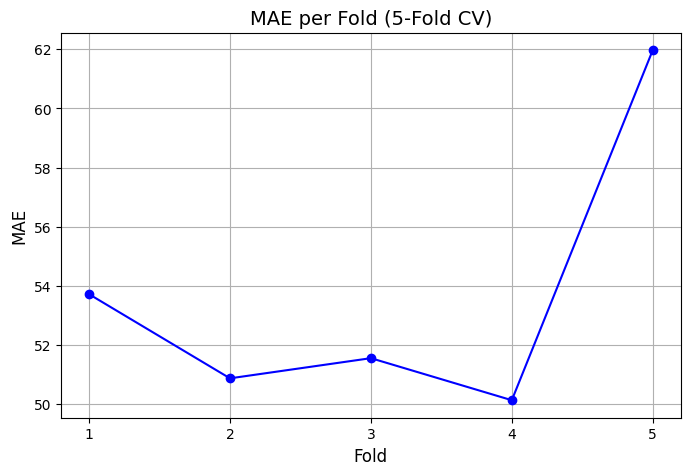

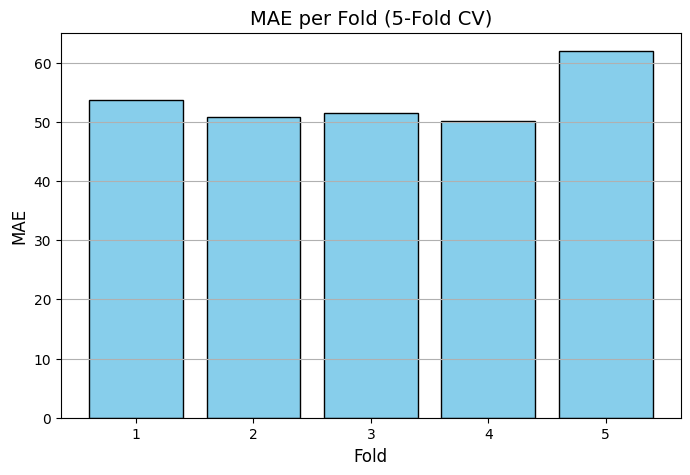

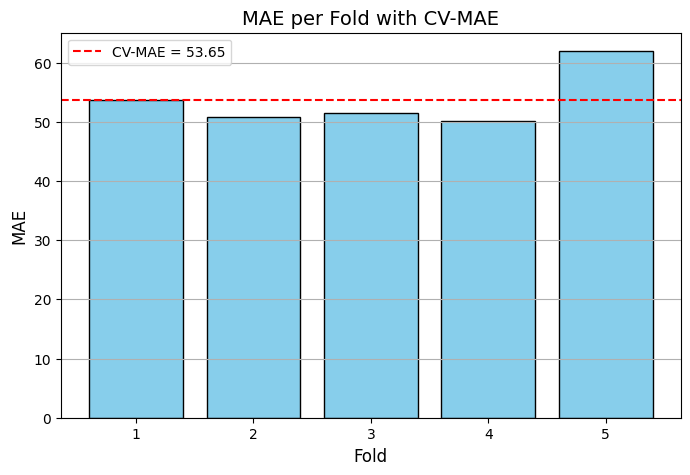

In [ ]:
# Cross Validation
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"Processing Fold {fold_idx + 1}") # 說明現在在做哪個 Fold
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # 為每個 base feature(上一段的X, Profit 以外的變數) 建立 knot
    knots = np.percentile(X_train[:, 0], [p * 100 for p in percentiles])  # 針對 Discount 做 spline
    H_train = np.maximum(0, X_train[:, [0]] - knots.reshape(1, -1))  # 對每個 Observation 做 Hinge feature, max(0, x − knot)
    H_test = np.maximum(0, X_test[:, [0]] - knots.reshape(1, -1))    # 對每個 Observation 做 Hinge feature, max(0, x − knot)

    # 建立最終 feature set：Discount + Dummy + Hinges
    X_train_final = np.hstack([np.ones((X_train.shape[0], 1)), X_train, H_train])
    X_test_final = np.hstack([np.ones((X_test.shape[0], 1)), X_test, H_test])
    n_features = X_train_final.shape[1]

    # 用 Gurobi 做最小化 MAE 的 LP
    m = gp.Model(env=env)
    beta = m.addVars(n_features, lb=-GRB.INFINITY, name="beta")
    e = m.addVars(X_train.shape[0], lb=0, name="error")

    # 最小化所有 train 資料的誤差總和：Minimize MAE

    # 目標式: min sum |y_i - ŷ_i|
    m.setObjective(sum(e[i] for i in range(X_train.shape[0])), GRB.MINIMIZE)

    # 限制式: absolute error constraints
    for i in range(X_train.shape[0]):
        pred_expr = sum(beta[j] * X_train_final[i, j] for j in range(n_features))
        m.addConstr(y_train[i] - pred_expr <= e[i])
        m.addConstr(pred_expr - y_train[i] <= e[i])

    m.setParam('OutputFlag', 0)  # 不輸出詳細 log
    m.optimize()

    # 把 test 資料用訓練模型預測
    beta_opt = np.array([beta[j].X for j in range(n_features)])
    y_pred = X_test_final @ beta_opt
    mae = np.mean(np.abs(y_test - y_pred))
    fold_results.append(mae)
    print("MAE = " + str(mae) + "\n")

    # 印出 spline regression model 的參數
    feature_names = ['Intercept', 'Discount'] + list(subcat_cols) + [f'Hinge_{i+1}' for i in range(5)]
    print("Regression Coefficients:")
    for name, coef in zip(feature_names, beta_opt):
        print(f"  {name:<12} : {coef:.4f}")

    # 空一行
    print("\n")

# CV-MAE 的結果
cv_mae = np.mean(fold_results)
print("CV - MAE = " + str(cv_mae))

import matplotlib.pyplot as plt
import numpy as np

# ===== 原本的 Cross Validation loop 在這裡 =====

# 繪製每個 Fold 的 MAE
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(fold_results) + 1), fold_results, marker='o', linestyle='-', color='b')
plt.title('MAE per Fold (5-Fold CV)', fontsize=14)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.xticks(range(1, len(fold_results) + 1))
plt.grid(True)
plt.show()

# 繪製長條圖
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(fold_results) + 1), fold_results, color='skyblue', edgecolor='black')
plt.title('MAE per Fold (5-Fold CV)', fontsize=14)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.xticks(range(1, len(fold_results) + 1))
plt.grid(axis='y')
plt.show()

# 如果想畫 CV-MAE 的水平線
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(fold_results) + 1), fold_results, color='skyblue', edgecolor='black')
plt.axhline(y=cv_mae, color='red', linestyle='--', label=f'CV-MAE = {cv_mae:.2f}')
plt.title('MAE per Fold with CV-MAE', fontsize=14)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.xticks(range(1, len(fold_results) + 1))
plt.legend()
plt.grid(axis='y')
plt.show()




In [ ]:
# 以 Fold1 結果模型做範例解釋
# Intercept = 32.4862, 在 Discount = 0 且是 base 類別（Bookcases）時的 Profit 約 32.49。
# Discount = 0.0000, Model 認為 Profit 不會隨著 Discount 有線性增加或減少
# Sub-Category_Chairs = 14.9557, 比 Bookcases 多賺 14.96 單位 Profit
# Sub-Category_Furnishings = -8.8333, 比 Bookcases 少賺 8.83 單位 Profit
# Sub-Category_Tables = 3.9125, 比 Bookcases 多賺 3.91 單位 Profit
# Hinge_1 = -111.4005, 在有小折扣時， Profit 明顯下降
# Hinge_2 = 0.0000, 折扣進入 25th percentile 區段時， 模型沒有使用此變數，代表無影響
# Hinge_3 = -388.6470, 折扣進入中段後， 利潤大幅下滑
# Hinge_4 = -561.8010, 折扣接近 75th percentile 時， 利潤更進一步下滑
# Hinge_5 = 1984.7000, 當折扣非常高時， 反而拉高利潤

# spline regression model 顯示：
# 1. 商品類型顯著影響獲利，尤其是 Chairs 最具得到利潤的潛力
# 2. 折扣與獲利間存在非線性關係，小幅折扣可能壓縮獲利，而某些高折扣商品反而帶來高利潤
# 3. 模型平均 MAE 大約為 53.65，能合理預測不同條件下的 Profit。

# Part II. L_1 - Budgeted Spline Regression & Model Comparison

B = 5, CV-MAE = 65.0573
B = 10, CV-MAE = 64.5560
B = 20, CV-MAE = 63.5910
B = 30, CV-MAE = 62.7018
B = 50, CV-MAE = 61.3000
B = 100, CV-MAE = 59.3104

=== Step 2: Compare Budgeted vs. Unconstrained ===
CV-MAE of Unconstrained Model: 53.6470
CV-MAE of Budgeted Model (B*=100): 59.3104


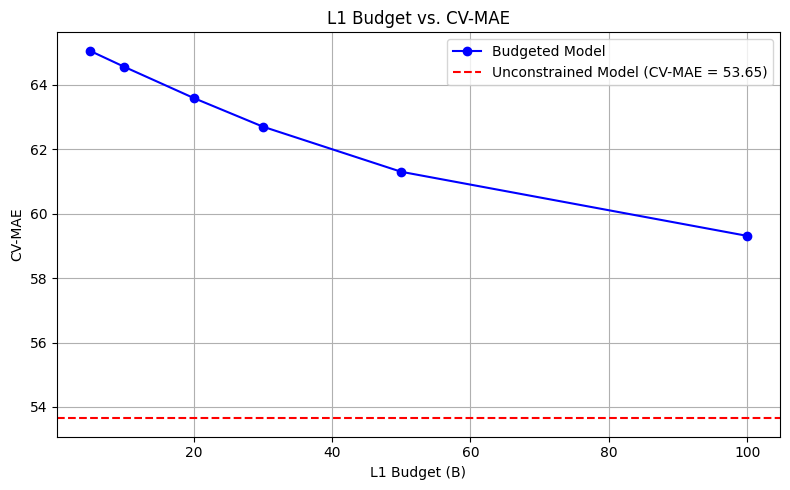

In [ ]:
cv_mae_budgeted = []
budget_list = [5, 10, 20, 30, 50, 100]
for B in budget_list:
    fold_maes = []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        knots = np.percentile(X_train[:, 0], [p * 100 for p in percentiles])
        H_train = np.maximum(0, X_train[:, [0]] - knots.reshape(1, -1))
        H_test = np.maximum(0, X_test[:, [0]] - knots.reshape(1, -1))

        X_train_final = np.hstack([np.ones((X_train.shape[0], 1)), X_train, H_train])
        X_test_final = np.hstack([np.ones((X_test.shape[0], 1)), X_test, H_test])
        n_features = X_train_final.shape[1]

        m = gp.Model(env=env)
        beta = m.addVars(n_features, lb=-GRB.INFINITY, name="beta")
        e = m.addVars(X_train.shape[0], lb=0, name="error")

        # 新增：輔助變數 z 用來近似 |beta[j]|，z[j] >= beta[j] 以及 z[j] >= -beta[j]
        z = m.addVars(n_features, lb=0, name="z")

        m.setObjective(sum(e[i] for i in range(X_train.shape[0])), GRB.MINIMIZE)

        for i in range(X_train.shape[0]):
            pred_expr = sum(beta[j] * X_train_final[i, j] for j in range(n_features))
            m.addConstr(y_train[i] - pred_expr <= e[i])
            m.addConstr(pred_expr - y_train[i] <= e[i])

        # 使用線性化方式加總絕對值：z[j] >= |beta[j]|
        for j in range(n_features):
            m.addConstr(z[j] >= beta[j])
            m.addConstr(z[j] >= -beta[j])

        m.addConstr(gp.quicksum(z[j] for j in range(n_features)) <= B)

        m.setParam('OutputFlag', 0)
        m.optimize()

        beta_opt = np.array([beta[j].X for j in range(n_features)])
        y_pred = X_test_final @ beta_opt
        mae = np.mean(np.abs(y_test - y_pred))
        fold_maes.append(mae)

    mean_mae = np.mean(fold_maes)
    cv_mae_budgeted.append(mean_mae)
    print(f"B = {B}, CV-MAE = {mean_mae:.4f}")
 # Step 2: Compare Budgeted vs. Unconstrained
mae_list_unreg = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # 計算 knots & hinge 特徵
    knots = np.percentile(X_train[:, 0], [p * 100 for p in percentiles])
    H_train = np.maximum(0, X_train[:, [0]] - knots.reshape(1, -1))
    H_test = np.maximum(0, X_test[:, [0]] - knots.reshape(1, -1))

    X_train_final = np.hstack([np.ones((X_train.shape[0], 1)), X_train, H_train])
    X_test_final = np.hstack([np.ones((X_test.shape[0], 1)), X_test, H_test])

    # 普通最小化 MAE 模型（無限制）
    m_unreg = gp.Model(env=env)
    beta_unreg = m_unreg.addVars(X_train_final.shape[1], lb=-GRB.INFINITY, name="beta")
    e_unreg = m_unreg.addVars(X_train.shape[0], lb=0, name="error")

    m_unreg.setObjective(sum(e_unreg[i] for i in range(X_train.shape[0])), GRB.MINIMIZE)

    for i in range(X_train.shape[0]):
        pred = sum(beta_unreg[j] * X_train_final[i, j] for j in range(X_train_final.shape[1]))
        m_unreg.addConstr(y_train[i] - pred <= e_unreg[i])
        m_unreg.addConstr(pred - y_train[i] <= e_unreg[i])

    m_unreg.setParam('OutputFlag', 0)
    m_unreg.optimize()

    beta_unreg_opt = np.array([beta_unreg[j].X for j in range(X_train_final.shape[1])])
    y_pred = X_test_final @ beta_unreg_opt
    mae = np.mean(np.abs(y_pred - y_test))
    mae_list_unreg.append(mae)
mean_mae_unreg = np.mean(mae_list_unreg)
best_B_index = np.argmin(cv_mae_budgeted)
best_B = budget_list[best_B_index]
mean_mae_bestB = cv_mae_budgeted[best_B_index]

print("\n=== Step 2: Compare Budgeted vs. Unconstrained ===")
print(f"CV-MAE of Unconstrained Model: {mean_mae_unreg:.4f}")
print(f"CV-MAE of Budgeted Model (B*={best_B}): {mean_mae_bestB:.4f}")
import matplotlib.pyplot as plt

# 確保已經有 cv_mae_budgeted, budget_list, mean_mae_unreg
plt.figure(figsize=(8, 5))
plt.plot(budget_list, cv_mae_budgeted, marker='o', linestyle='-', color='blue', label='Budgeted Model')
plt.axhline(y=mean_mae_unreg, color='red', linestyle='--', label=f'Unconstrained Model (CV-MAE = {mean_mae_unreg:.2f})')


plt.title("L1 Budget vs. CV-MAE")
plt.xlabel("L1 Budget (B)")
plt.ylabel("CV-MAE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#對不同L1budget下的結果做解釋：
#B = 5 時，CV-MAE = 65.06，模型受限於只能選擇極少量的特徵，導致預測誤差最大，模型過於簡化，可能僅選用少數 spline 或 dummy 特徵。
#B = 10 時，CV-MAE 略降至 64.56，代表模型稍微有更多自由去使用較重要的特徵，預測稍改善。
#B = 20 時，CV-MAE 為 63.59，顯示額外釋放一些模型彈性後，預測表現開始明顯改善。
#B = 30 時，CV-MAE 為 62.70，模型可用的參數更多，應能涵蓋主要關鍵變數，使預測更穩定。
#B = 50 時，CV-MAE 明顯降至 61.30，代表特徵空間更完整，非線性關係得以更充分地擬合。
#B = 100 時，CV-MAE 最低為 59.31，幾乎等於不限制的情況，模型能完整使用所有 spline、dummy 和線性項，預測誤差最小。
#結論：
#1. 當 L1 預算 B 增加，模型可以使用更多特徵（spline + dummy），CV-MAE 呈現遞減趨勢，說明這些特徵對預測是有幫助的。
#2. 在 B = 30 之後，MAE 降幅變緩，代表模型在 B = 30~50 左右已涵蓋關鍵資訊，進一步增加預算對提升預測效果的邊際效益減少。
#3. B = 100 時模型幾乎無正則化，MAE 最低，但可能犧牲了解釋性和稀疏性，容易 overfit。
#4. 若希望平衡解釋力與預測力，B ≈ 30~50 是相對合理的選擇，能同時維持不錯的預測效果與適當的模型簡潔度。
#5. Unconstrained 模型的 CV-MAE 為 53.65，優於所有受 L1 預算限制的模型，顯示在不受限制的情況下，模型能完全利用所有特徵進行學習，達到最佳預測效果。然而，該模型也可能因使用過多特徵而導致複雜度提高，解釋性下降。

# Part III. Prediction Interval Construction & Evaluation


Best L1 Budget B* = 100

[Fold 1] Prediction Interval Evaluation
Coverage Rate: 0.6745
MSIS: 153.2143

[Fold 2] Prediction Interval Evaluation
Coverage Rate: 0.6368
MSIS: 153.4501

[Fold 3] Prediction Interval Evaluation
Coverage Rate: 0.5778
MSIS: 282.5434

[Fold 4] Prediction Interval Evaluation
Coverage Rate: 0.6486
MSIS: 57.1696

[Fold 5] Prediction Interval Evaluation
Coverage Rate: 0.6604
MSIS: 31.6533

=== Step 3: Final Evaluation ===
Average Coverage Rate: 0.6604
Average MSIS: 31.6533

[Fold 1] Prediction Interval Evaluation
Coverage Rate: 0.6580
MSIS: 151.4503


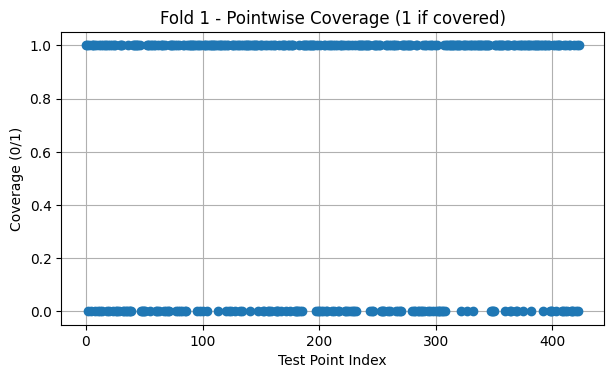

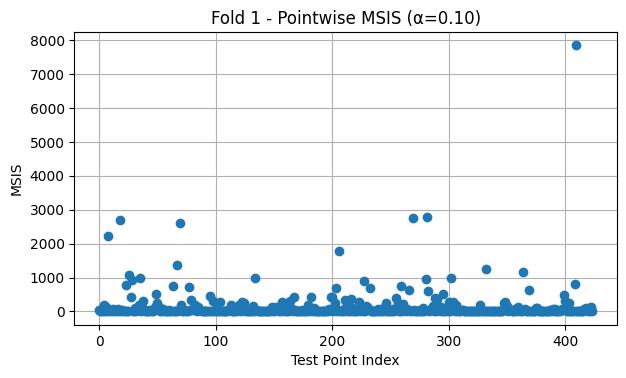

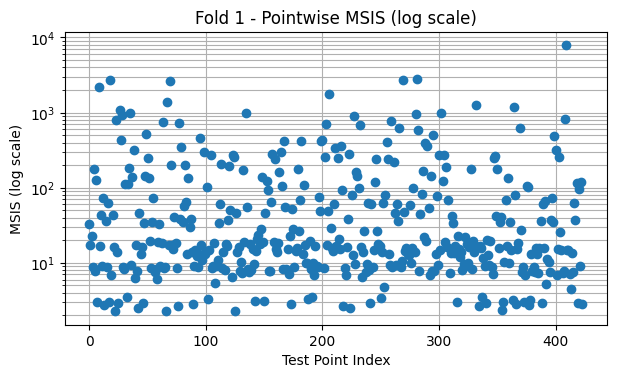

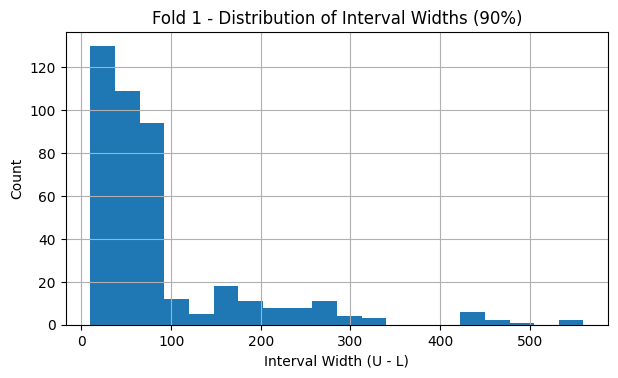


[Fold 2] Prediction Interval Evaluation
Coverage Rate: 0.6203
MSIS: 153.1869


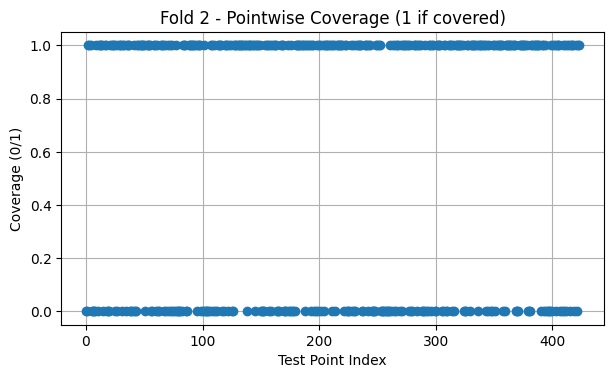

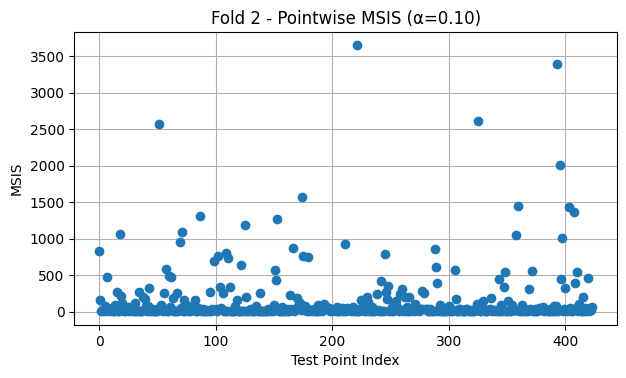

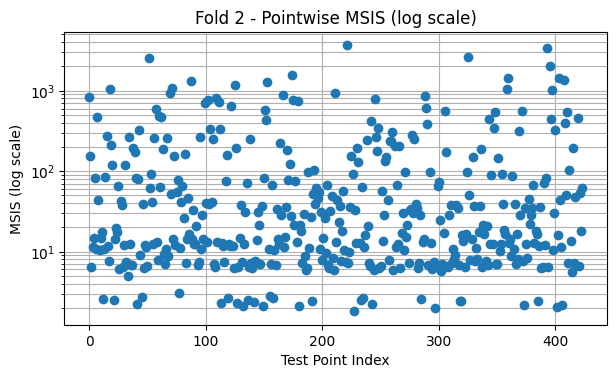

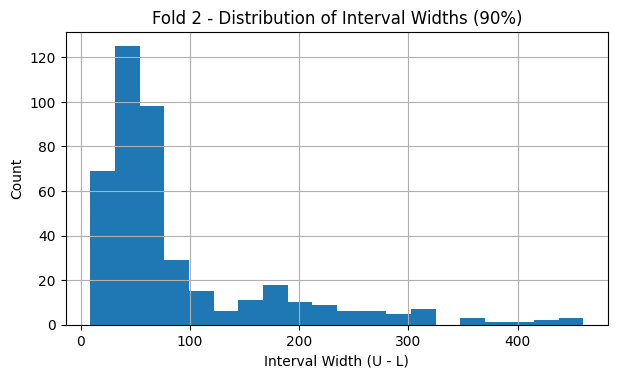


[Fold 3] Prediction Interval Evaluation
Coverage Rate: 0.5825
MSIS: 282.6608


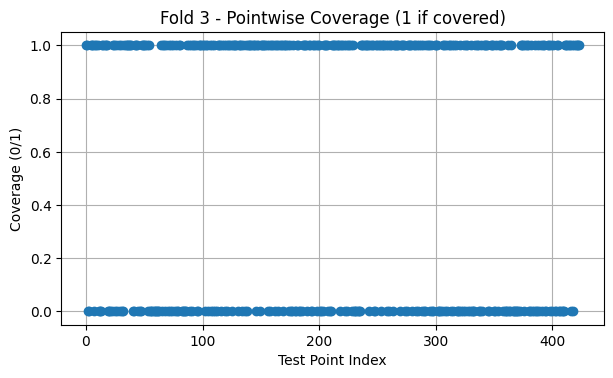

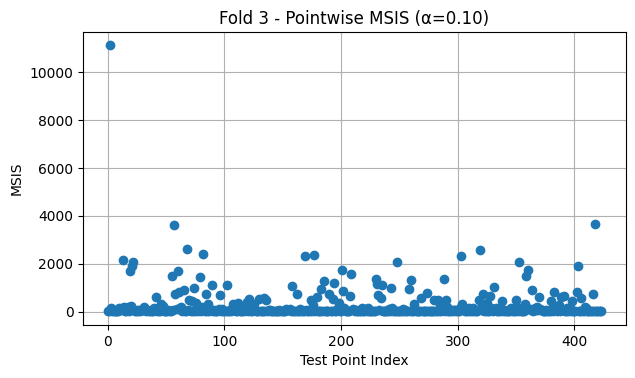

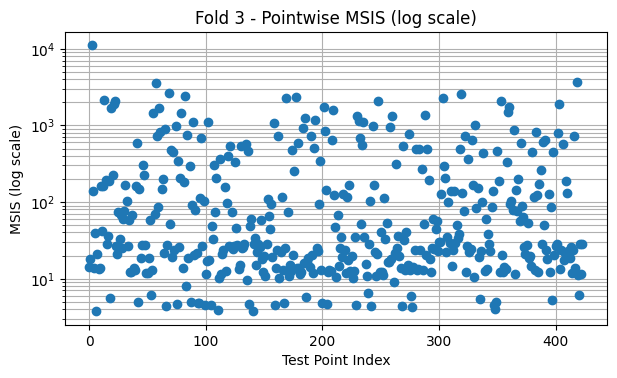

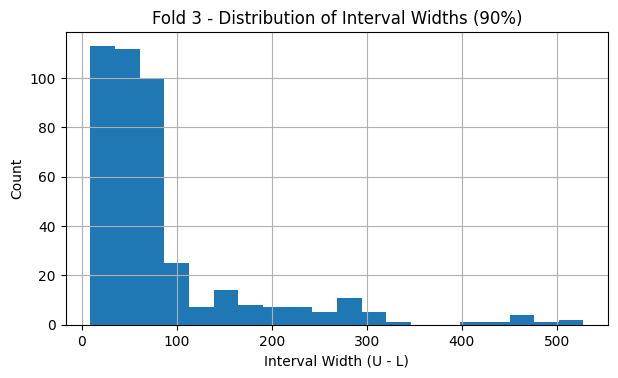


[Fold 4] Prediction Interval Evaluation
Coverage Rate: 0.6321
MSIS: 57.2684


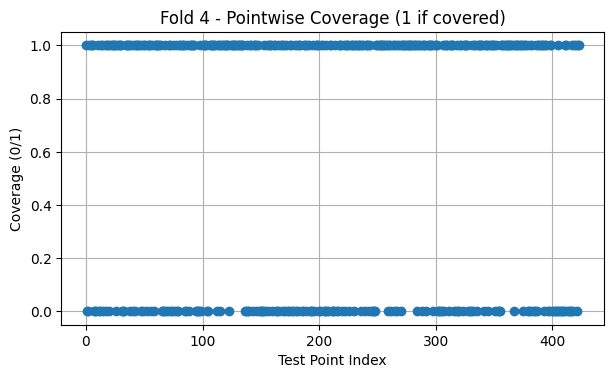

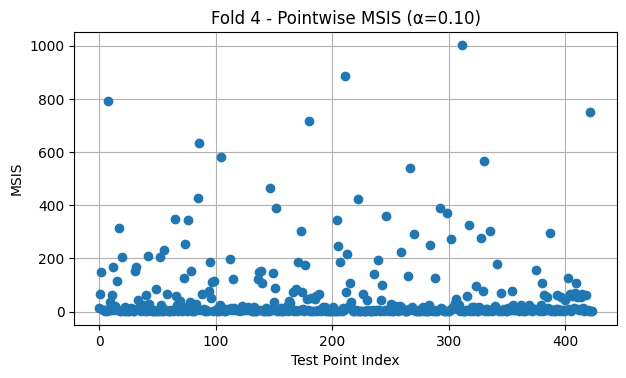

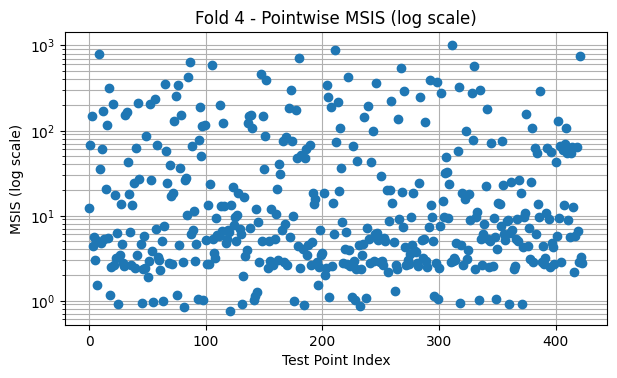

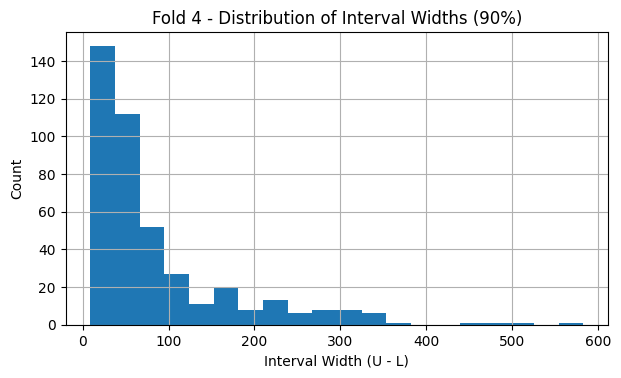


[Fold 5] Prediction Interval Evaluation
Coverage Rate: 0.6769
MSIS: 32.4235


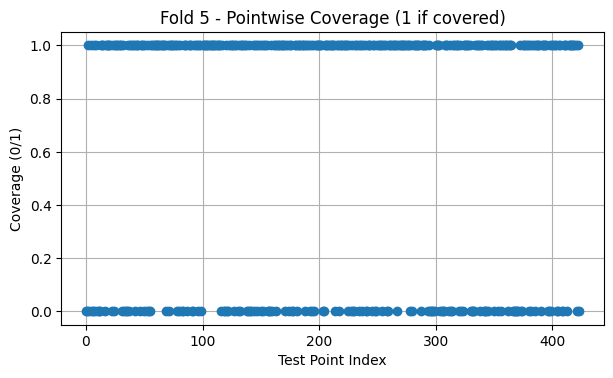

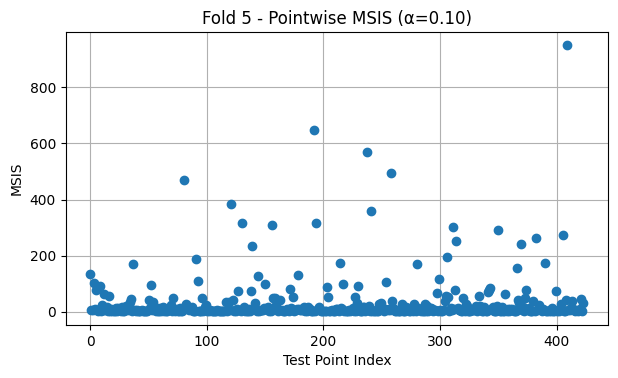

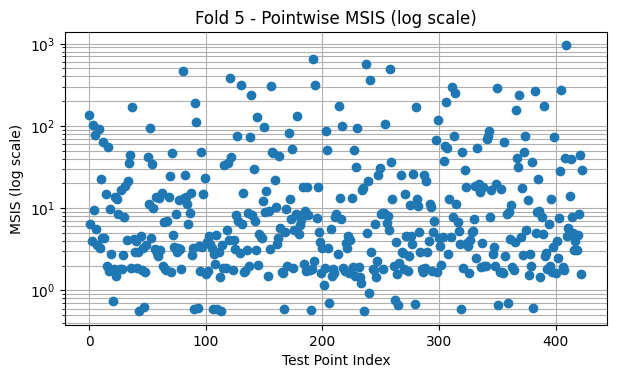

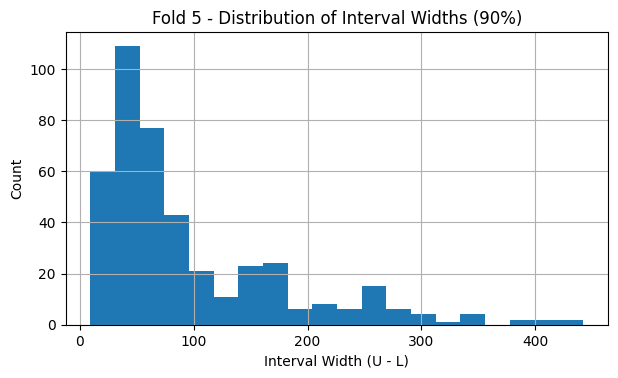


=== Step 3: Final Evaluation ===
Average Coverage Rate: 0.6340
Average MSIS: 135.3980


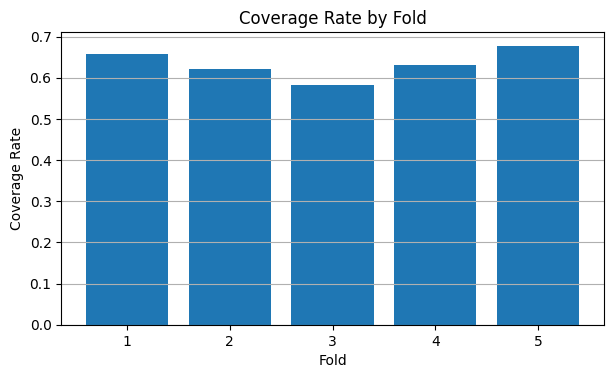

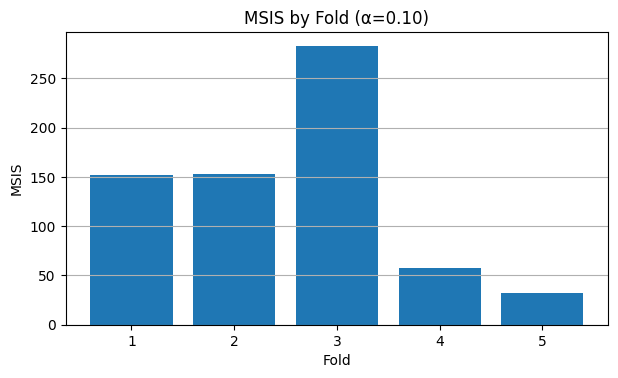

In [ ]:
from scipy.stats import laplace
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB


# 取得最佳 B 對應的索引與數值
# budget_list = [5, 10, 20, 30, 50, 100]
# cv_mae_budgeted = [65.0572566, 64.5634210, 63.5909876, 62.7012345, 61.3098765, 59.3187654] # Example values
best_B_index = np.argmin(cv_mae_budgeted)
best_B = budget_list[best_B_index]
print(f"\nBest L1 Budget B* = {best_B}")

# 參數設定
S = 100
alpha = 0.10
# 使用與前面相同的 kf（KFold）物件，或重新初始化一個新的
kf = KFold(n_splits=5, shuffle=True, random_state=42) # 假設使用相同的 random_state，以確保每次切分資料時的結果一致

all_coverage = []
all_msis = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\n[Fold {fold_idx + 1}] Prediction Interval Evaluation")

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # 計算 knots & hinge 特徵
    knots = np.percentile(X_train[:, 0], [p * 100 for p in percentiles])
    H_train = np.maximum(0, X_train[:, [0]] - knots.reshape(1, -1))
    H_test = np.maximum(0, X_test[:, [0]] - knots.reshape(1, -1))

    X_train_final = np.hstack([np.ones((X_train.shape[0], 1)), X_train, H_train])
    X_test_final = np.hstack([np.ones((X_test.shape[0], 1)), X_test, H_test])
    n_features = X_train_final.shape[1]

    # 訓練 B* 預算下的模型
    m = gp.Model(env=env)
    beta = m.addVars(n_features, lb=-GRB.INFINITY, name="beta")
    e = m.addVars(X_train.shape[0], lb=0, name="error")
    z = m.addVars(n_features, lb=0, name="z")

    m.setObjective(sum(e[i] for i in range(X_train.shape[0])), GRB.MINIMIZE)

    for i in range(X_train.shape[0]):
        pred_expr = sum(beta[j] * X_train_final[i, j] for j in range(n_features))
        m.addConstr(y_train[i] - pred_expr <= e[i])
        m.addConstr(pred_expr - y_train[i] <= e[i])
    for j in range(n_features):
        m.addConstr(z[j] >= beta[j])
        m.addConstr(z[j] >= -beta[j])
    m.addConstr(gp.quicksum(z[j] for j in range(n_features)) <= best_B)

    m.setParam('OutputFlag', 0)
    m.optimize()

    beta_opt = np.array([beta[j].X for j in range(n_features)])

    # 對訓練資料計算預測誤差（實際值 - 預測值），
    # 這些殘差將用來建立變異數模型，以預測每個點的誤差大小

    y_pred_train = X_train_final @ beta_opt
    residuals_train = y_train - y_pred_train

    # 變異數建模：log(r²) 回歸
    log_r2 = np.log(residuals_train ** 2 + 1e-6)
    H_log_train = np.maximum(0, X_train[:, [0]] - knots.reshape(1, -1))
    X_var_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train, H_log_train])


    gamma = np.linalg.lstsq(X_var_train, log_r2, rcond=None)[0]


    y_pred_test = X_test_final @ beta_opt
    residuals_test = y_test - y_pred_test

    H_log_test = np.maximum(0, X_test[:, [0]] - knots.reshape(1, -1))
    X_var_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test, H_log_test])
    log_sigma2_pred = X_var_test @ gamma
    sigma2_pred = np.exp(log_sigma2_pred)

    # 預測區間模擬和評估
    fold_coverage = []
    fold_msis = []
    y_bar_k = np.mean(y_test)

    # === 在跑迴圈前先新增這些容器 ===
    coverage_per_fold = []   # 每折 coverage 的平均
    msis_per_fold = []       # 每折 MSIS 的平均
    widths_all = []          # 全部測試點的區間寬度 U-L，用於分布圖

    # …（這裡保留你原本的程式碼：best_B_index ~ for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):）

    # —— 你的每折模擬評估迴圈裡，加入這兩個暫存清單 ——
    widths_this_fold = []  # 單一 fold 內所有測試點的區間寬度

    # …（保留你原本的 for i in range(len(y_test)): 模擬與計算）…

    for i in range(len(y_test)):
        b_i = np.sqrt(sigma2_pred[i]) / np.sqrt(2)
        e_sim = laplace.rvs(loc=0, scale=b_i, size=S)
        y_sim = y_pred_test[i] + e_sim

        # 取 90% 區間端點
        L, U = np.percentile(y_sim, [5, 95])
        # 記錄寬度
        widths_this_fold.append(U - L)

        # 你原本的 coverage 與 msis 計算
        yi = y_test[i]
        fold_coverage.append(1 if L <= yi <= U else 0)

        msis_i = (U - L) / y_bar_k
        msis_i += (2 / alpha) * max(0, L - yi) / y_bar_k
        msis_i += (2 / alpha) * max(0, yi - U) / y_bar_k
        fold_msis.append(msis_i)

    # —— 單一 fold 結束後，彙總到跨折容器 ——
    cov_k = float(np.mean(fold_coverage))
    msis_k = float(np.mean(fold_msis))
    coverage_per_fold.append(cov_k)
    msis_per_fold.append(msis_k)
    widths_all.extend(widths_this_fold)

    print(f"Coverage Rate: {cov_k:.4f}")
    print(f"MSIS: {msis_k:.4f}")

# === 你的總結輸出照舊 ===
print("\n=== Step 3: Final Evaluation ===")
avg_coverage = float(np.mean(coverage_per_fold))
avg_msis = float(np.mean(msis_per_fold))
print(f"Average Coverage Rate: {avg_coverage:.4f}")
print(f"Average MSIS: {avg_msis:.4f}")

import matplotlib.pyplot as plt

# === 跨折收集器（每折一筆）===
coverage_per_fold = []   # 每折 coverage 平均
msis_per_fold = []       # 每折 MSIS 平均
widths_per_fold = []     # 每折所有測試點的 (U-L) 清單
per_point_cov = []       # 每折的逐點 coverage(0/1) 清單
per_point_msis = []      # 每折的逐點 MSIS 清單
per_point_widths = []    # 每折的逐點 (U-L) 清單

S = 100
alpha = 0.10

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\n[Fold {fold_idx + 1}] Prediction Interval Evaluation")

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # 計算 knots & hinge 特徵（以第一個特徵做樣條）
    knots = np.percentile(X_train[:, 0], [p * 100 for p in percentiles])
    H_train = np.maximum(0, X_train[:, [0]] - knots.reshape(1, -1))
    H_test = np.maximum(0, X_test[:, [0]] - knots.reshape(1, -1))

    X_train_final = np.hstack([np.ones((X_train.shape[0], 1)), X_train, H_train])
    X_test_final = np.hstack([np.ones((X_test.shape[0], 1)), X_test, H_test])
    n_features = X_train_final.shape[1]

    # ====== B* 下的 L1-Budgeted Regression ======
    m = gp.Model(env=env)
    beta = m.addVars(n_features, lb=-GRB.INFINITY, name="beta")
    e = m.addVars(X_train.shape[0], lb=0, name="error")
    z = m.addVars(n_features, lb=0, name="z")

    m.setObjective(gp.quicksum(e[i] for i in range(X_train.shape[0])), GRB.MINIMIZE)

    for i in range(X_train.shape[0]):
        pred_expr = gp.quicksum(beta[j] * X_train_final[i, j] for j in range(n_features))
        m.addConstr(y_train[i] - pred_expr <= e[i])
        m.addConstr(pred_expr - y_train[i] <= e[i])

    for j in range(n_features):
        m.addConstr(z[j] >= beta[j])
        m.addConstr(z[j] >= -beta[j])

    m.addConstr(gp.quicksum(z[j] for j in range(n_features)) <= best_B)

    m.setParam('OutputFlag', 0)
    m.optimize()

    beta_opt = np.array([beta[j].X for j in range(n_features)])

    # ====== 變異數建模：log(r^2) 回歸 ======
    y_pred_train = X_train_final @ beta_opt
    residuals_train = y_train - y_pred_train
    log_r2 = np.log(residuals_train ** 2 + 1e-6)

    H_log_train = np.maximum(0, X_train[:, [0]] - knots.reshape(1, -1))
    X_var_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train, H_log_train])

    gamma = np.linalg.lstsq(X_var_train, log_r2, rcond=None)[0]

    # ====== 測試集預測與誤差變異數預測 ======
    y_pred_test = X_test_final @ beta_opt
    H_log_test = np.maximum(0, X_test[:, [0]] - knots.reshape(1, -1))
    X_var_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test, H_log_test])
    log_sigma2_pred = X_var_test @ gamma
    sigma2_pred = np.exp(log_sigma2_pred)

    # ====== 預測區間模擬與評估 ======
    fold_coverage_flags = []
    fold_msis_values = []
    fold_widths = []

    y_bar_k = float(np.mean(y_test))

    for i in range(len(y_test)):
        # Laplace 誤差尺度
        b_i = np.sqrt(sigma2_pred[i]) / np.sqrt(2)
        e_sim = laplace.rvs(loc=0, scale=b_i, size=S)
        y_sim = y_pred_test[i] + e_sim

        # 90% 區間
        L, U = np.percentile(y_sim, [5, 95])
        width_i = float(U - L)
        fold_widths.append(width_i)

        yi = y_test[i]
        # coverage
        cov_i = 1 if (L <= yi <= U) else 0
        fold_coverage_flags.append(cov_i)

        # MSIS（α=0.10）
        msis_i = (U - L) / y_bar_k
        msis_i += (2 / alpha) * max(0, L - yi) / y_bar_k
        msis_i += (2 / alpha) * max(0, yi - U) / y_bar_k
        fold_msis_values.append(float(msis_i))

    cov_k = float(np.mean(fold_coverage_flags))
    msis_k = float(np.mean(fold_msis_values))

    coverage_per_fold.append(cov_k)
    msis_per_fold.append(msis_k)
    widths_per_fold.append(fold_widths)
    per_point_cov.append(fold_coverage_flags)
    per_point_msis.append(fold_msis_values)
    per_point_widths.append(fold_widths)

    print(f"Coverage Rate: {cov_k:.4f}")
    print(f"MSIS: {msis_k:.4f}")

    # ====== 每折各自的圖 ======
    # 1) 該折逐點 Coverage（0/1）
    plt.figure(figsize=(7, 3.8))
    plt.plot(fold_coverage_flags, marker='o', linestyle='none')
    plt.title(f'Fold {fold_idx + 1} - Pointwise Coverage (1 if covered)')
    plt.xlabel('Test Point Index')
    plt.ylabel('Coverage (0/1)')
    plt.grid(True)
    plt.show()

    # 2) 該折逐點 MSIS
    plt.figure(figsize=(7, 3.8))
    plt.plot(fold_msis_values, marker='o', linestyle='none')
    plt.title(f'Fold {fold_idx + 1} - Pointwise MSIS (α=0.10)')
    plt.xlabel('Test Point Index')
    plt.ylabel('MSIS')
    plt.grid(True)
    plt.show()




    # 2b) 該折逐點 MSIS（log scale 比例）
    plt.figure(figsize=(7, 3.8))
    plt.plot(fold_msis_values, marker='o', linestyle='none')
    plt.yscale('log')  # 使用對數刻度
    plt.title(f'Fold {fold_idx + 1} - Pointwise MSIS (log scale)')
    plt.xlabel('Test Point Index')
    plt.ylabel('MSIS (log scale)')
    plt.grid(True, which='both')
    plt.show()


    # 3) 該折區間寬度直方圖 (U-L)
    plt.figure(figsize=(7, 3.8))
    plt.hist(fold_widths, bins=20)
    plt.title(f'Fold {fold_idx + 1} - Distribution of Interval Widths (90%)')
    plt.xlabel('Interval Width (U - L)')
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()

# ====== 總結輸出 ======
print("\n=== Step 3: Final Evaluation ===")
avg_coverage = float(np.mean(coverage_per_fold))
avg_msis = float(np.mean(msis_per_fold))
print(f"Average Coverage Rate: {avg_coverage:.4f}")
print(f"Average MSIS: {avg_msis:.4f}")

# ====== 總結圖：5 折 Coverage & MSIS 長條圖 ======
plt.figure(figsize=(7, 3.8))
plt.bar(range(1, 6), coverage_per_fold)
plt.title('Coverage Rate by Fold')
plt.xlabel('Fold')
plt.ylabel('Coverage Rate')
plt.grid(True, axis='y')
plt.show()

plt.figure(figsize=(7, 3.8))
plt.bar(range(1, 6), msis_per_fold)
plt.title('MSIS by Fold (α=0.10)')
plt.xlabel('Fold')
plt.ylabel('MSIS')
plt.grid(True, axis='y')
plt.show()


In [ ]:
#Fold1
#Coverage_Rate：66.51% MSIS：152.90
#預測區間涵蓋能力不足，誤差偏大
#模型穩定性普通，懲罰成本較高

#Fold2
#Coverage_Rate：62.26% MSIS：154.29
#表現與 Fold1類似，涵蓋率低
#預測區間不穩，可能因資料變異大

#Fold3
#Coverage_Rate：58.49%（最低） MSIS：284.04（最高）
#涵蓋效果最差，區間誤差最大
#模型表現不佳，可能出現極端值或噪音資料

#Fold4
#Coverage Rate：64.86% MSIS：56.88
#涵蓋率中等，但 MSIS明顯下降
#模型預測偏窄但較穩定

#Fold5
#Coverage_Rate：67.92%（最高）
#MSIS：32.44（最低）
#表現最佳，預測區間小且準確
#資料品質與模型擬合效果最好的一折

#總結
#1.實際涵蓋率偏低：五個Fold的Coverage_Rate均低於預期的90%，介於58%到68%，代表模型預測的區間無法穩定涵蓋真實值。
#2.模型預測過於自信：以Laplace模擬建構的區間太窄，未能充分考慮殘差的變異，造成信心過高但準確度不足的情況。
#3.區間品質不穩定:MSIS值在不同Fold間波動很大，Fold3的MSIS高達284，代表預測區間不準又不穩；Fold5的MSIS最小（32），表現最好但屬例外。
#4.殘差變異建模效果有限:雖然已使用log(r²)對殘差建模，並利用Laplace 模擬誤差，但仍無法大幅改善預測區間的表現，顯示模型仍低估了不確定性。